In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Exercise 6.4
def simulate_exchange_rate(X0, r, rf, sigmaX, T, N):
    """  
    X0 = initial exchange rate
    r = domestic risk-free rate
    rf = foreign risk-free rate
    sigmaX = volatility of the exchange rate
    T = time to maturity
    N = number of time steps

    plots path and forward rate
    returns time increments, simulated path, and forward rate
    """

    dt = T / N
    time_points = np.linspace(0, T, N+1)
    exchange_rate_path = np.zeros(N+1)
    exchange_rate_path[0] = X0

    for i in range(1, N+1):
        z = np.random.randn()
        exchange_rate_path[i] = exchange_rate_path[i-1] * np.exp((r-rf-0.5*sigmaX**2)*dt + sigmaX * np.sqrt(dt) * z)

    
    forward_rate = X0 * np.exp((r-rf)*T)

    plt.figure(figsize=(10,6))
    plt.plot(time_points, exchange_rate_path)
    plt.axhline(y=forward_rate, color='red', linestyle='--', label='Forward Rate at T')
    plt.title('Exchange Rate Simulation')
    plt.xlabel('Time')
    plt.ylabel('Exchange Rate')
    plt.legend()
    plt.show()

    return time_points, exchange_rate_path, forward_rate

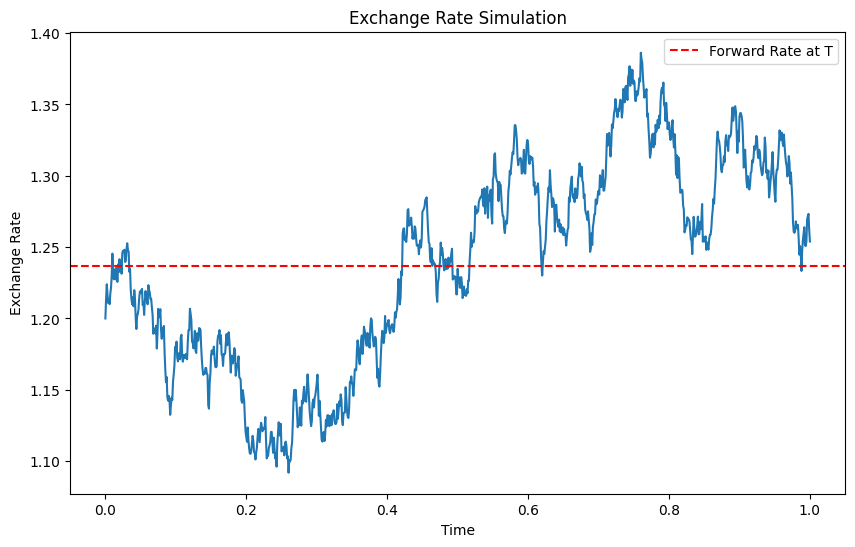

(array([0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ]),
 array([1.2       , 1.21378245, 1.22396633, ..., 1.27329866, 1.26168876,
        1.25395842]),
 np.float64(1.2365454407442202))

In [4]:
# Set parameters
X0 = 1.2
r = 0.05
rf = 0.02
sigmaX = 0.2
T = 1
N = 1000

simulate_exchange_rate(X0, r, rf, sigmaX, T, N)

In [5]:
# Exercise 6.5
def simulate_hedged_portfolio(X0, sigmaX, mu, S0, r, rf, sigmaS, q, rho, Xbar, T, N):
    """  
    X0 = initial exchange rate
    sigmaX = volatility of exchange rate
    mu = expected growth of exchange rate
    S0 = initial stock price
    r = domestic risk-free rate
    rf = foreign risk-free rate
    sigmaS = volatility of the stock price
    q = dividend yield of the foreign asset
    rho = correlation between exchange rate and asset price
    Xbar = agreed upon fixed exchange rate
    T = maturity of the forward contract
    N = number of time periods

    returns gain/loss of hedged portfolio, simulated paths of exchange rate and asset price
    """

    dt = T / N
    time_points = np.linspace(0, T, N+1)

    X_path = np.zeros(N+1)
    S_path = np.zeros(N+1)
    X_path[0] = X0
    S_path[0] = S0

    for i in range(1, N+1):
        z1 = np.random.randn()
        z2 = np.random.randn()

        dBX = z1 * np.sqrt(dt)
        dBS = rho * z1 * np.sqrt(dt) + np.sqrt(1-rho**2) * z2 * np.sqrt(dt)

        X_path[i] = X_path[i-1] * np.exp((mu-0.5*sigmaX**2)*dt + sigmaX*dBX)
        S_path[i] = S_path[i-1] * np.exp((rf-q-0.5*sigmaS**2)*dt + sigmaS*dBS)

    
    # Initial hedged portfolio
    V0 = Xbar * S_path[-1] * np.exp(-r*T) # Intial value to meet promised payment
    V = V0
    cash = V0
    shares = 0

    for i in range(1, N+1):
        t = time_points[i]
        Xt = X_path[i]
        St = S_path[i]

        # Textbook equation (6.14)
        hedge_ratio = (Xbar/Xt) * np.exp((rf-r-q-rho*sigmaX*sigmaS)*(T-t))
        new_cash_position = V - hedge_ratio*Xt*St

        cash = cash * np.exp(-r*dt) + (shares - hedge_ratio) * Xt*St
        shares = hedge_ratio

        V = cash + shares * Xt * St

    profit = V - Xbar * S_path[-1]

    plt.figure(figsize=(10,6))
    plt.plot(time_points, X_path, label='Exchange Rate (X)')
    plt.plot(time_points, S_path, label='Stock Price (S)')
    plt.title('Simulated Exchange Rate and Stock Price')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return profit, X_path, S_path


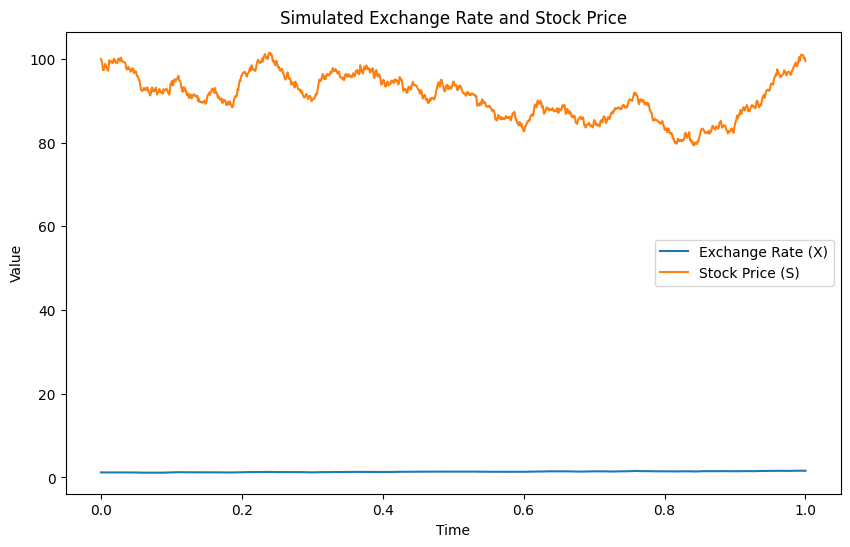

Hedged Porfolio Profit: 26.82807046031168


In [6]:
# Set parameters
X0 = 1.2
r = 0.05
rf = 0.02
sigmaX = 0.15
T = 1
N = 1000
mu = 0.02
S0 = 100
sigmaS = 0.2
q = 0.03
rho = 0.5
Xbar = 1.2

profit, X_path, S_path = simulate_hedged_portfolio(X0, sigmaX, mu, S0, r, rf, sigmaS, q, rho, Xbar, T, N)
print('Hedged Porfolio Profit:', profit)

In [11]:
# Exercise 6.6
def simulate_forward_hedged_portfolio(X0, sigmaX, mu, S0, r, rf, sigmaS, q, rho, Xbar, T, N):
    """  
    X0 = initial exchange rate
    sigmaX = volatility of exchange rate
    mu = expected growth of exchange rate
    S0 = initial stock price
    r = domestic risk-free rate
    rf = foreign risk-free rate
    sigmaS = volatility of the stock price
    q = dividend yield of the foreign asset
    rho = correlation between exchange rate and asset price
    Xbar = agreed upon fixed exchange rate
    T = maturity of the forward contract
    N = number of time periods

    returns gain/loss from forward-hedged portfolio, simulated paths of exchange rate adn stock price
    """

    dt = T / N
    time_points = np.linspace(0, T, N+1)

    X_path = np.zeros(N+1)
    S_path = np.zeros(N+1)
    X_path[0] = X0
    S_path[0] = S0

    for i in range(1, N+1):
        z1 = np.random.randn()
        z2 = np.random.randn()

        dBX = z1 * np.sqrt(dt)
        dBS = rho * z1 * np.sqrt(dt) + np.sqrt(1-rho**2) * z2 * np.sqrt(dt)

        X_path[i] = X_path[i-1] * np.exp((mu-0.5*sigmaX**2)*dt + sigmaX*dBX)
        S_path[i] = S_path[i-1] * np.exp((rf-q-0.5*sigmaS**2)*dt + sigmaS*dBS)


    # Initialize forward hedge
    V0 = Xbar * S_path[-1] * np.exp(-r*T)
    V = V0
    net_forward_profit = 0  # Variable to track net gain/loss

    for i in range(1, N+1):
        t = time_points[i]
        Xt = X_path[i]
        St = S_path[i]

        forward_price = Xt * np.exp((r-rf)*(T-t))
        
        forward_position = (Xbar/Xt) * np.exp((rf-r-q-rho*sigmaX*sigmaS)*(T-t))
        forward_position += forward_position * (forward_price - Xbar)

        net_forward_profit += forward_position * (forward_price - Xbar)

    profit = net_forward_profit + V - Xbar * S_path[-1]

    plt.figure(figsize=(10,6))
    plt.plot(time_points, X_path, label='Exchange Rate (X)')
    plt.plot(time_points, S_path, label='Stock Price (S)')
    plt.title('Simulated Exchange Rate and Stock Price')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return profit, X_path, S_path

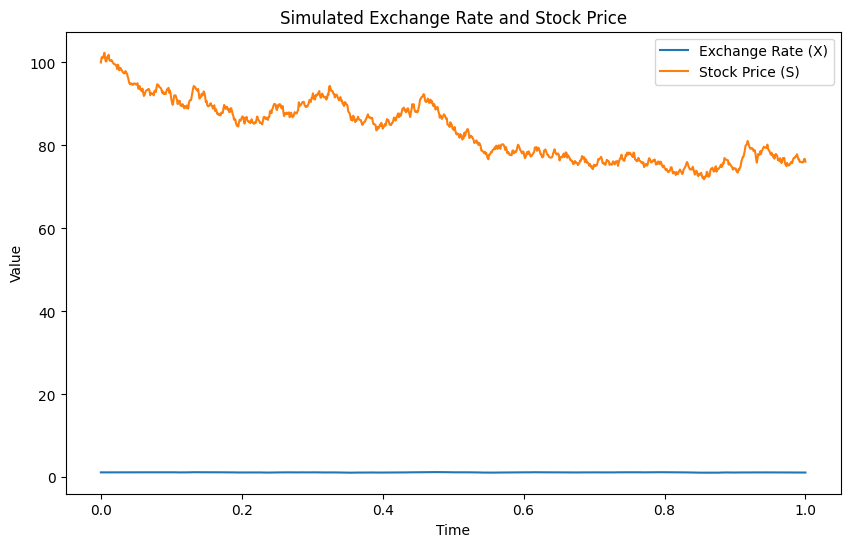

Hedged Porfolio Profit: 11.062473271692895


In [12]:
# Set parameters
X0 = 1.2
r = 0.05
rf = 0.02
sigmaX = 0.15
T = 1
N = 1000
mu = 0.02
S0 = 100
sigmaS = 0.2
q = 0.03
rho = 0.5
Xbar = 1.2

profit, X_path, S_path = simulate_forward_hedged_portfolio(X0, sigmaX, mu, S0, r, rf, sigmaS, q, rho, Xbar, T, N)
print('Hedged Porfolio Profit:', profit)